# Notebook 02: Exploratory Data Analysis
**Philippine NCR Pump Price Forecasting**

This notebook performs a systematic EDA on all features and the DOE pump price targets.
We follow the methodology of:
- **Ljubić et al. (2023)** — stationarity testing (ADF), ACF/PACF, data shifting experiment
- **He (2023)** — seasonality decomposition, correlation analysis
- **Lunor et al. (2023)** — Philippine pump price behavior, structural break identification

### On keeping only ONE crude oil benchmark
We have Brent, WTI, and Dubai crude. Research justification for our choice:
- **Dubai** is the correct benchmark for Asian-Pacific refiners (our methodology doc §1.1)
- **Brent** is freely available daily from EIA and is the standard in global literature
- **WTI** is US-centric and less relevant for Philippine pricing
- Brent and WTI correlate >0.95 — keeping both causes multicollinearity without adding information

**Decision**: Use **Brent** as primary (daily, free, literature standard). Keep **Dubai** as robustness check (monthly, from FRED). Drop WTI after EDA confirms redundancy.
This mirrors Lunor et al. who used Dubai Crude (DCO) as their crude oil feature.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import os
os.makedirs('../outputs', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [3]:
master = pd.read_parquet('data/final/master_weekly.parquet')

PRODUCTS  = ['diesel', 'ron91', 'ron95', 'ron97']
CRUDE_ALL = ['brent_mean', 'wti_mean', 'dubai_close']
FEATURES  = ['brent_mean', 'usd_php_mean', 'mops_gasoil_mean', 'mops_rbob_mean', 'cpi_value', 'dubai_close']

# Event dates — structural breaks we must account for
EVENTS = {
    'TRAIN tranche 1 (Jan 2018)': ('2018-01-01', 'navy'),
    'TRAIN tranche 2 (Jan 2019)': ('2019-01-01', 'navy'),
    'TRAIN tranche 3 (Jan 2020)': ('2020-01-01', 'navy'),
    'COVID lockdown (Mar 2020)':  ('2020-03-16', 'orange'),
    'Russia-Ukraine (Feb 2022)':  ('2022-02-24', 'red'),
}

print('Shape:', master.shape)
print('Date range:', master.index.min(), '->', master.index.max())
master.tail()

Shape: (373, 15)
Date range: 2018-02-12 00:00:00 -> 2026-04-27 00:00:00


,usd_php_mean,brent_mean,wti_mean,mops_gasoil_mean,mops_rbob_mean,dubai_close,cpi_value,rub_usd_mean,diesel,diesel_plus,kerosene,ron100,ron91,ron95,ron97
week_monday,,,,,,,,,,,,,,,
2026-03-30,59.841000,111.242,94.292,189.149402,130.331038,126.706364,127.2,0.012262,131.550,140.000,154.75,102.950,93.700,98.3025,107.300
2026-04-06,60.456999,123.935,105.670,204.551247,136.953600,126.706364,127.2,0.012380,147.800,155.700,163.05,104.500,94.950,97.1000,106.425
2026-04-13,59.842799,124.605,104.544,209.639999,131.521320,126.706364,127.2,0.012655,123.600,129.500,155.30,97.625,87.150,90.3000,99.050
2026-04-20,59.952801,114.432,93.840,191.773001,129.302881,126.706364,127.2,0.013160,98.700,100.525,146.95,92.400,82.990,84.6500,92.400
2026-04-27,60.025600,109.618,95.430,192.018002,139.517280,126.706364,127.2,0.013279,85.275,87.800,131.45,89.225,81.775,82.5250,91.500


## 1. Data Coverage and Missingness

In [4]:
print('=== NULL COUNTS PER COLUMN ===')
nulls = master.isnull().sum().sort_values(ascending=False)
print(nulls[nulls > 0])
print(f'\nTotal rows: {len(master)}')
print(f'Complete rows (no nulls): {master.dropna().shape[0]}')

=== NULL COUNTS PER COLUMN ===
ron100         27
diesel          3
diesel_plus     3
kerosene        3
dtype: int64

Total rows: 373
Complete rows (no nulls): 346


## 2. Pump Price Time Series with Structural Breaks

Following Lunor et al. (2023), we annotate key events that create structural breaks in the price series: TRAIN excise law tranches, COVID lockdowns, and the Russia-Ukraine conflict.

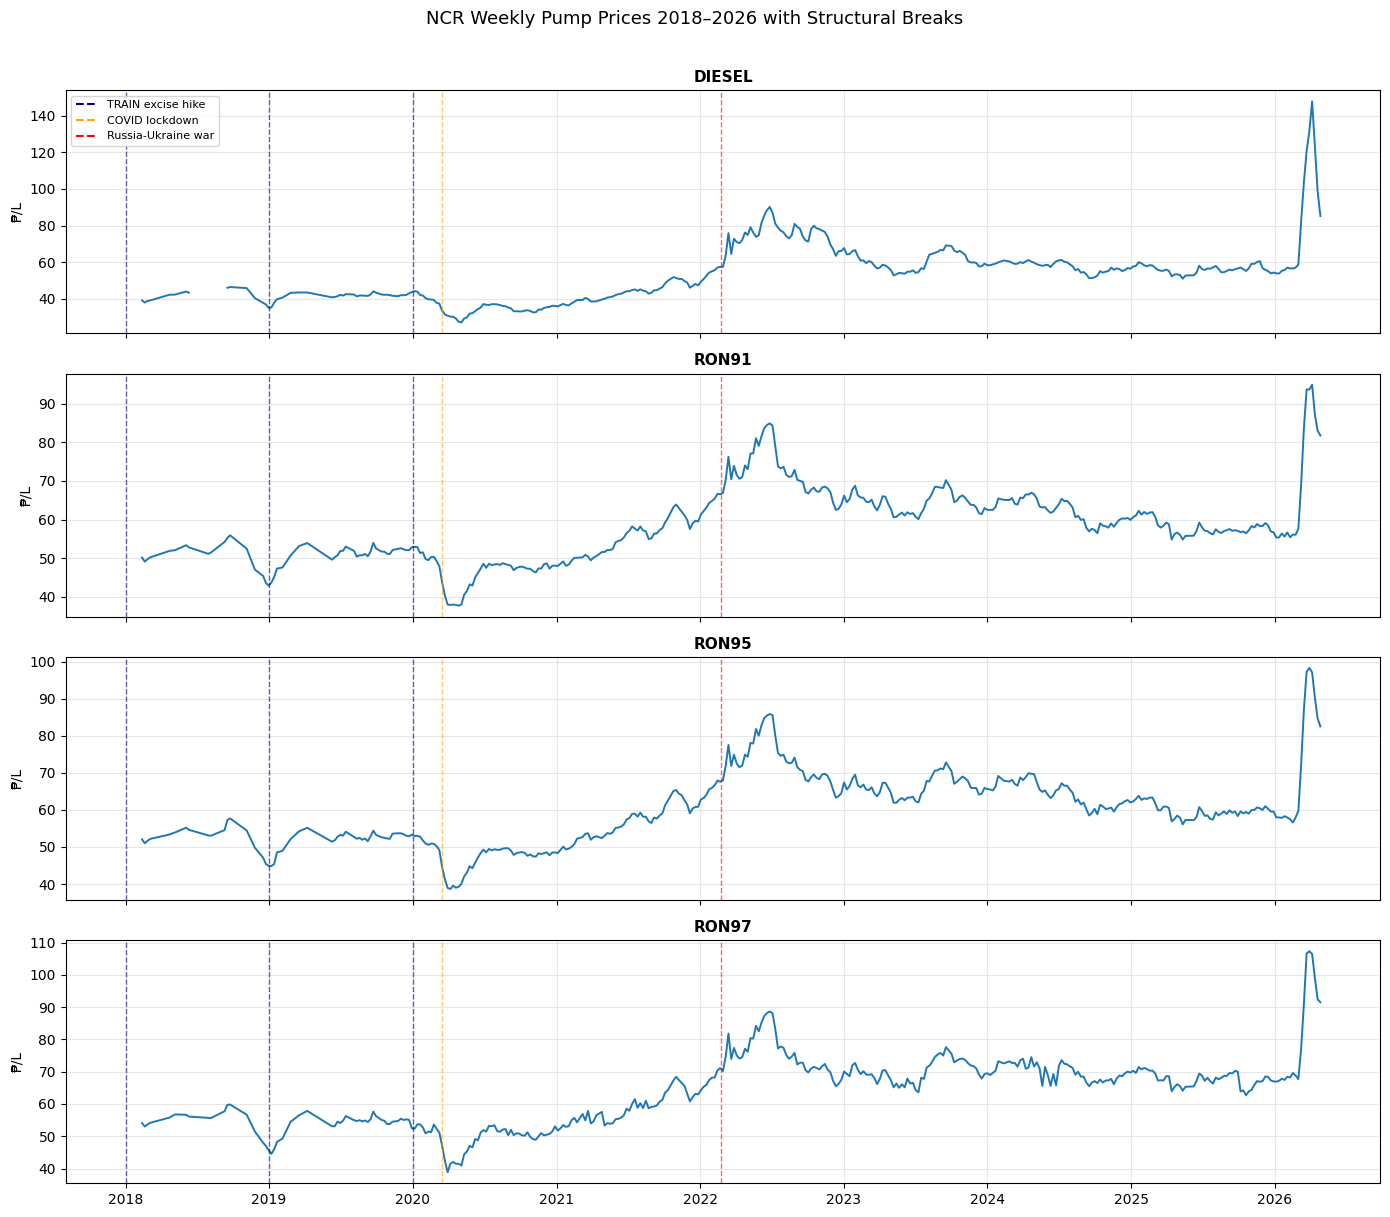

Saved: 02_pump_prices_timeseries.png


In [5]:
available_products = [p for p in PRODUCTS if p in master.columns]

fig, axes = plt.subplots(len(available_products), 1, figsize=(14, 3*len(available_products)), sharex=True)
if len(available_products) == 1:
    axes = [axes]

for ax, product in zip(axes, available_products):
    ax.plot(master.index, master[product], linewidth=1.4, label=product.upper())
    for label, (date, color) in EVENTS.items():
        ax.axvline(pd.Timestamp(date), color=color, linestyle='--', alpha=0.6, linewidth=1.0)
    ax.set_ylabel('₱/L', fontsize=10)
    ax.set_title(product.upper(), fontsize=11, weight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

# Legend for events
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], color='navy', linestyle='--', label='TRAIN excise hike'),
                   Line2D([0],[0], color='orange', linestyle='--', label='COVID lockdown'),
                   Line2D([0],[0], color='red', linestyle='--', label='Russia-Ukraine war')]
axes[0].legend(handles=legend_elements, fontsize=8, loc='upper left')

plt.suptitle('NCR Weekly Pump Prices 2018–2026 with Structural Breaks', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/02_pump_prices_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_pump_prices_timeseries.png')

## 3. Should we keep Brent, WTI, or Dubai? — Pairwise Correlation Test

Per our methodology, we have three crude oil proxies. Economic theory (§1.1 of the methodology) says Dubai is the 'correct' benchmark for Asian refiners, but it is monthly. Brent is the literature standard and is daily. WTI is US-centric.

We resolve this empirically: if Brent and WTI correlate >0.95, they are redundant. We keep Brent (more relevant globally) and Dubai (as robustness feature, forward-filled monthly).

=== CRUDE OIL CORRELATION MATRIX ===
             brent_mean  wti_mean  dubai_close
brent_mean       1.0000    0.9910       0.9661
wti_mean         0.9910    1.0000       0.9548
dubai_close      0.9661    0.9548       1.0000



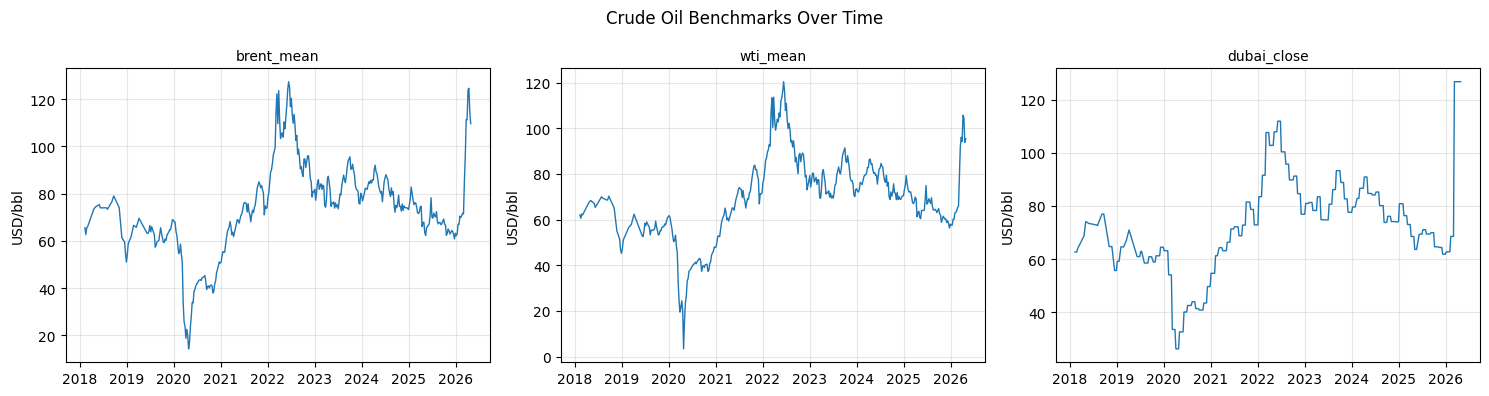

Brent-WTI correlation: 0.9910
=> Brent and WTI are >0.95 correlated. DROPPING WTI to avoid multicollinearity.
=> Keeping: Brent (primary, daily) + Dubai (robustness, monthly-ffilled)
=> This is consistent with Lunor et al. (2023) who used Dubai Crude as their crude feature.


In [6]:
crude_available = [c for c in CRUDE_ALL if c in master.columns]
crude_df = master[crude_available].dropna()

print('=== CRUDE OIL CORRELATION MATRIX ===')
print(crude_df.corr().round(4))
print()

fig, axes = plt.subplots(1, len(crude_available), figsize=(5*len(crude_available), 4))
if len(crude_available) == 1:
    axes = [axes]

for ax, col in zip(axes, crude_available):
    ax.plot(crude_df.index, crude_df[col], linewidth=1.0)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('USD/bbl')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

plt.suptitle('Crude Oil Benchmarks Over Time', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/02b_crude_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

if 'brent_mean' in crude_df and 'wti_mean' in crude_df:
    corr_bw = crude_df['brent_mean'].corr(crude_df['wti_mean'])
    print(f'Brent-WTI correlation: {corr_bw:.4f}')
    if corr_bw > 0.95:
        print('=> Brent and WTI are >0.95 correlated. DROPPING WTI to avoid multicollinearity.')
        print('=> Keeping: Brent (primary, daily) + Dubai (robustness, monthly-ffilled)')
        print('=> This is consistent with Lunor et al. (2023) who used Dubai Crude as their crude feature.')

## 4. Feature Time Series — All Features

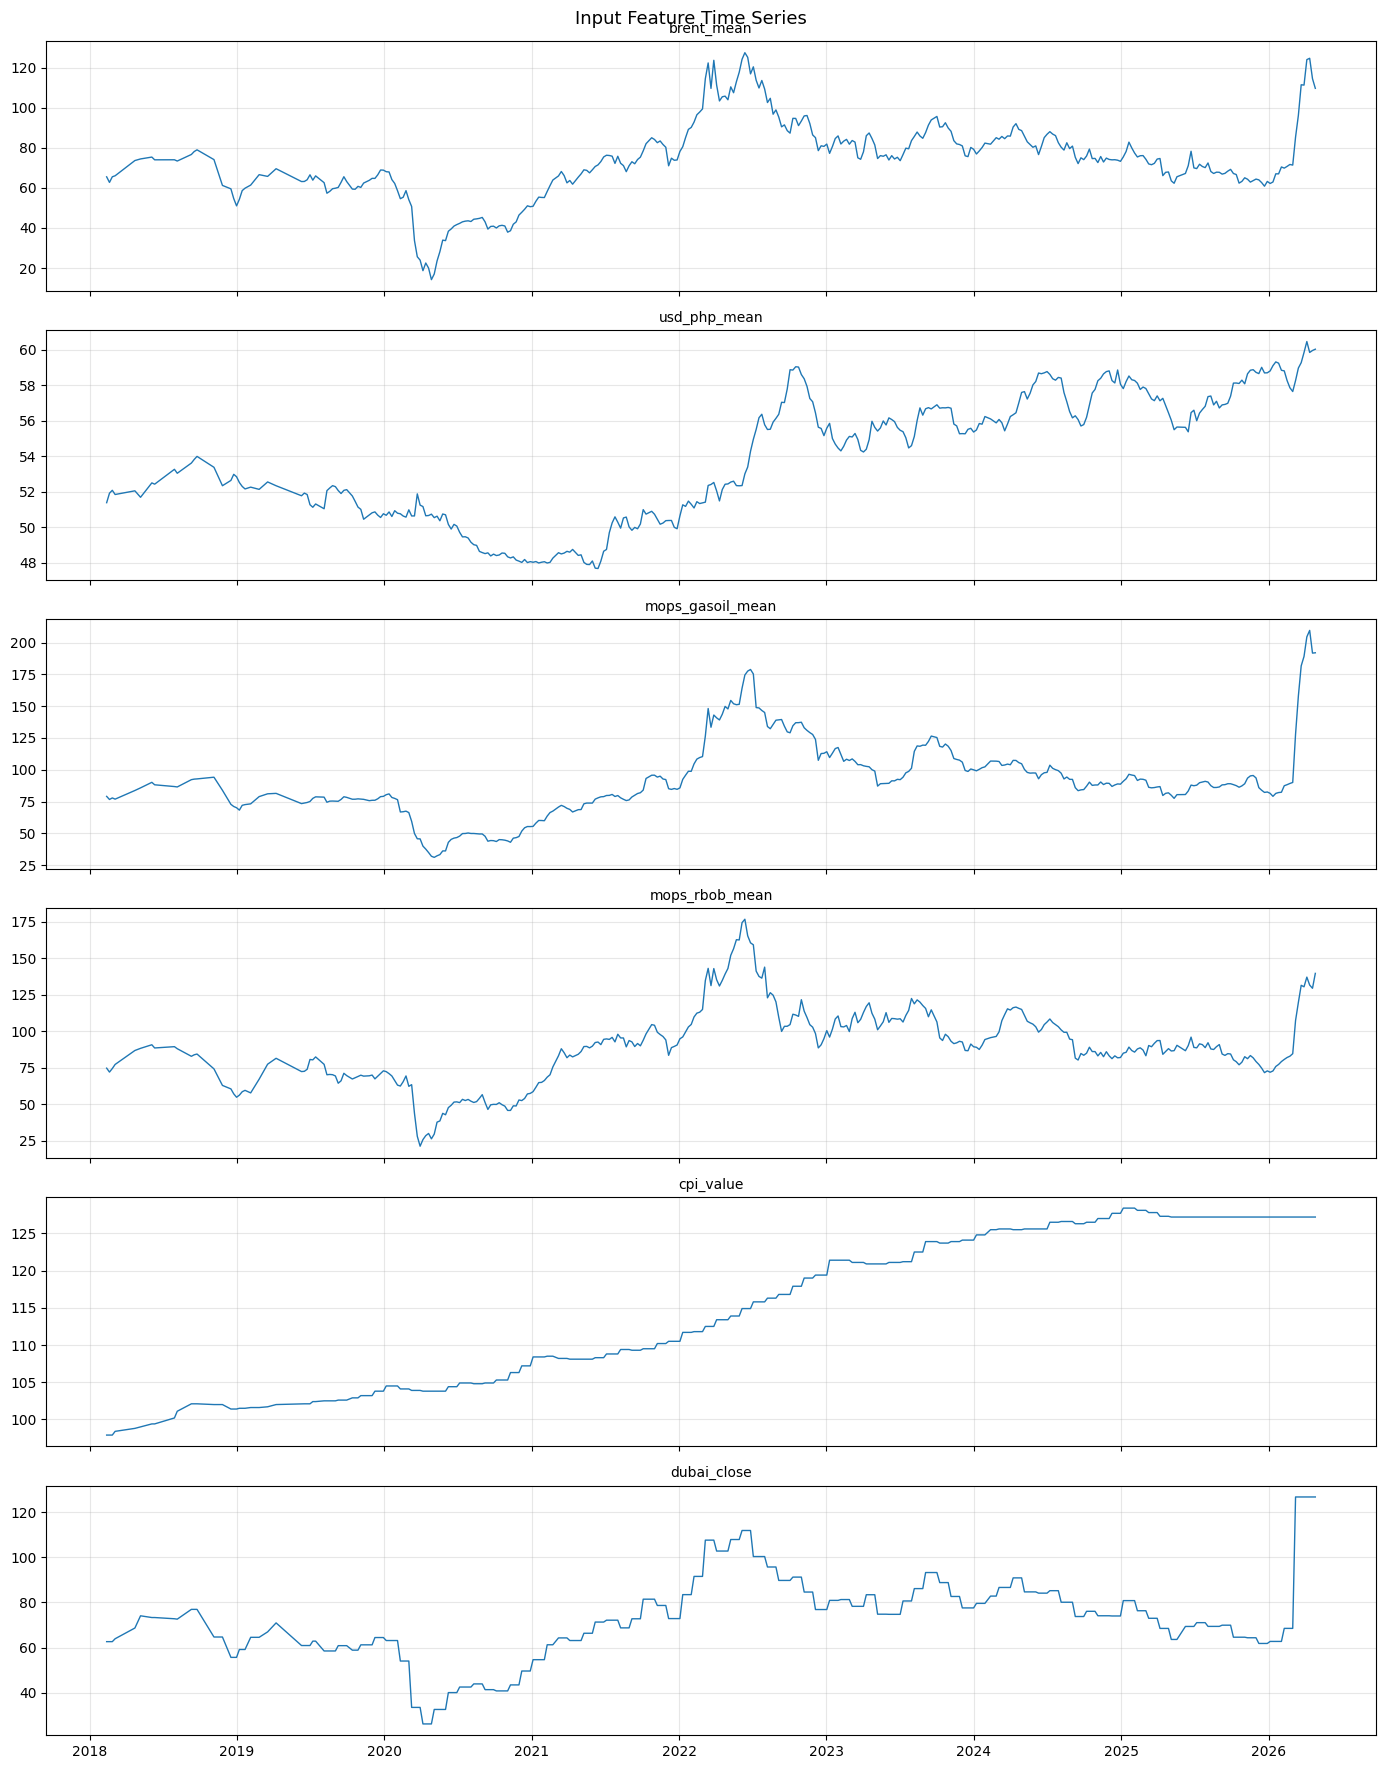

In [7]:
feat_available = [f for f in FEATURES if f in master.columns and f != 'wti_mean']

fig, axes = plt.subplots(len(feat_available), 1, figsize=(14, 3*len(feat_available)), sharex=True)
if len(feat_available) == 1:
    axes = [axes]

for ax, feat in zip(axes, feat_available):
    ax.plot(master.index, master[feat], linewidth=1.0)
    ax.set_title(feat, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

plt.suptitle('Input Feature Time Series', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/02c_feature_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Matrix — Features vs Pump Prices

Following He (2023) Figure 5, we compute a full correlation matrix. This tells us which features are most predictive and which are redundant (high inter-feature correlation = multicollinearity problem for OLS, handled by Ridge/Lasso).

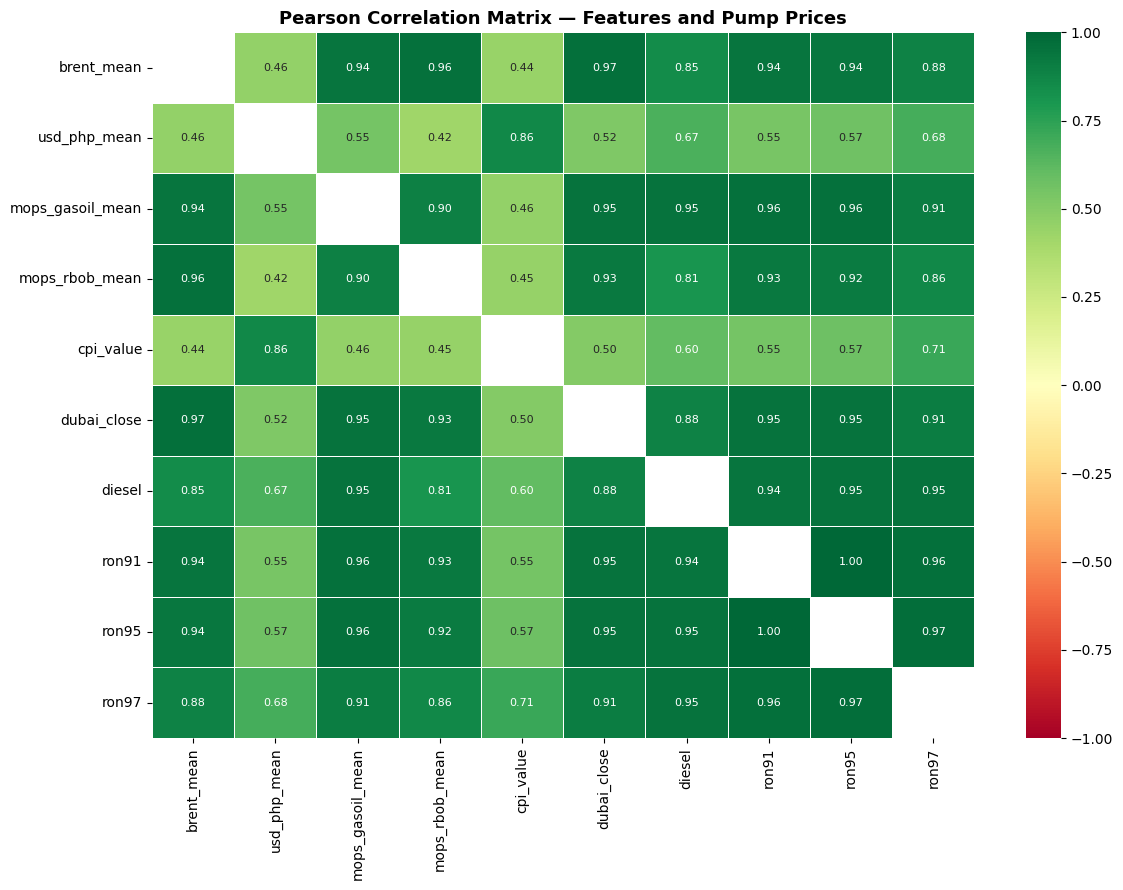


=== CORRELATION WITH DIESEL ===
ron95               0.9466
mops_gasoil_mean    0.9464
ron97               0.9456
ron91               0.9436
dubai_close         0.8850
brent_mean          0.8501
mops_rbob_mean      0.8083
usd_php_mean        0.6655
cpi_value           0.6020
Name: diesel, dtype: float64


In [8]:
analysis_cols = feat_available + available_products
corr_df = master[analysis_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, mask=mask,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Pearson Correlation Matrix — Features and Pump Prices', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('../outputs/02d_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print feature-to-diesel correlations for reference
print('\n=== CORRELATION WITH DIESEL ===')
if 'diesel' in corr_matrix:
    print(corr_matrix['diesel'].drop('diesel').sort_values(ascending=False).round(4))

## 6. Stationarity Testing (Augmented Dickey-Fuller)

Following Ljubić et al. (2023) §4.5, we apply the ADF test to determine if each series is stationary. A stationary series has no unit root (p < 0.05). Most price series in levels will be non-stationary — this is expected and motivates our use of returns/differences in feature engineering.

In [9]:
def adf_test(series, name):
    s = series.dropna()
    if len(s) < 20:
        print(f'{name:35s} | Too few observations')
        return
    result = adfuller(s, autolag='AIC')
    pval = result[1]
    stat = result[0]
    status = '✅ STATIONARY' if pval < 0.05 else '❌ NON-STATIONARY'
    print(f'{name:35s} | ADF={stat:7.3f} | p={pval:.4f} | {status}')

print('=' * 80)
print('ADF TEST — PRICE LEVELS')
print('=' * 80)
for col in available_products + feat_available:
    if col in master.columns:
        adf_test(master[col], col)

print()
print('=' * 80)
print('ADF TEST — FIRST DIFFERENCES (weekly changes)')
print('=' * 80)
for col in available_products + feat_available:
    if col in master.columns:
        adf_test(master[col].diff().dropna(), f'Δ{col}')

ADF TEST — PRICE LEVELS
diesel                              | ADF= -0.907 | p=0.7857 | ❌ NON-STATIONARY
ron91                               | ADF= -1.480 | p=0.5433 | ❌ NON-STATIONARY
ron95                               | ADF= -1.480 | p=0.5435 | ❌ NON-STATIONARY
ron97                               | ADF= -1.230 | p=0.6605 | ❌ NON-STATIONARY
brent_mean                          | ADF= -2.091 | p=0.2481 | ❌ NON-STATIONARY
usd_php_mean                        | ADF= -0.721 | p=0.8414 | ❌ NON-STATIONARY
mops_gasoil_mean                    | ADF= -1.424 | p=0.5707 | ❌ NON-STATIONARY
mops_rbob_mean                      | ADF= -1.694 | p=0.4341 | ❌ NON-STATIONARY
cpi_value                           | ADF= -1.122 | p=0.7062 | ❌ NON-STATIONARY
dubai_close                         | ADF= -1.715 | p=0.4232 | ❌ NON-STATIONARY

ADF TEST — FIRST DIFFERENCES (weekly changes)
Δdiesel                             | ADF= -9.383 | p=0.0000 | ✅ STATIONARY
Δron91                              | ADF= -7.940 | p

## 7. ACF and PACF — Diesel Price (Primary Target)

ACF and PACF reveal the autocorrelation structure of the price series. High autocorrelation at lag 1 (expected: ~0.95) confirms the 'persistence' baseline is strong, and motivates why MASE (vs. naive persistence) is our primary evaluation metric.

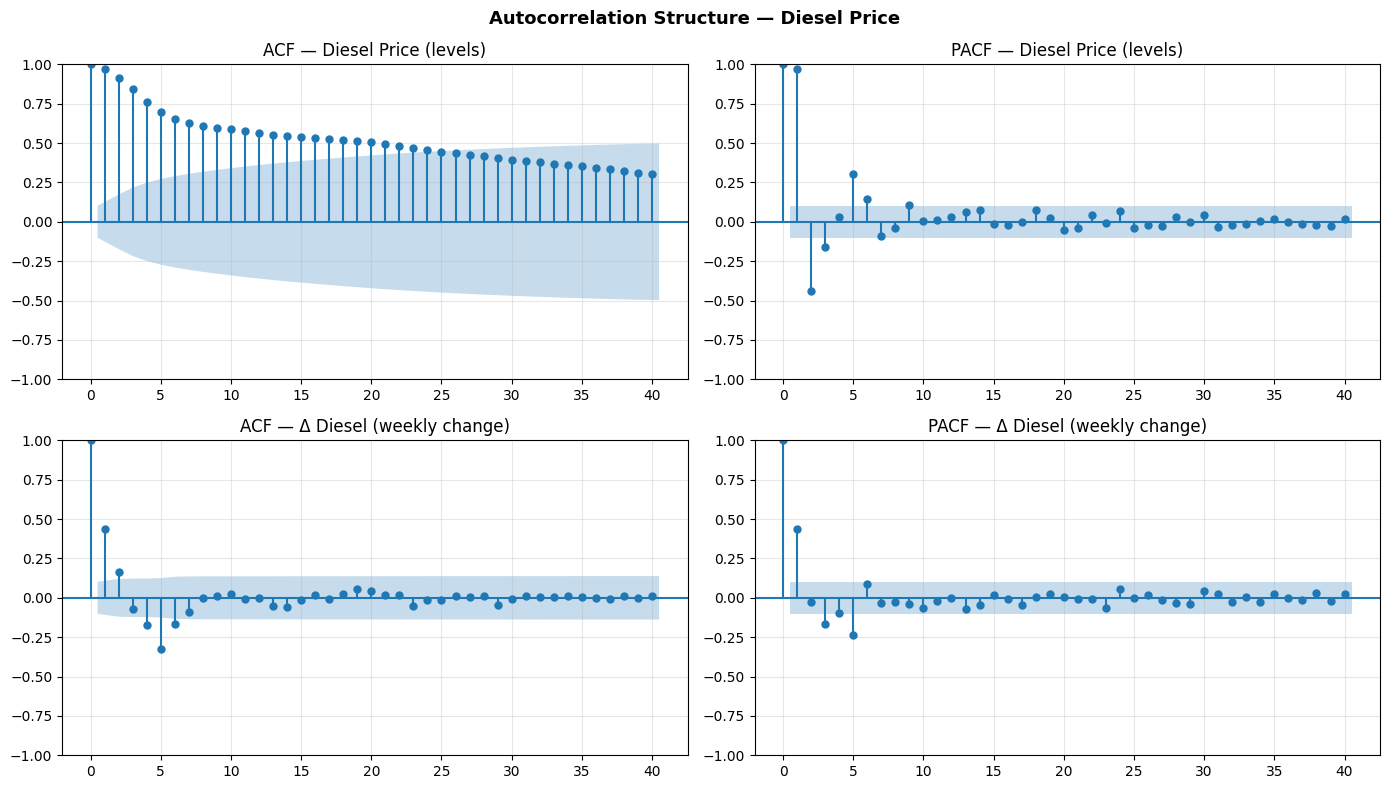

Lag-1 autocorrelation of diesel price: 0.9694
(~0.95 expected — confirms persistence baseline will be hard to beat)


In [10]:
if 'diesel' in master.columns:
    series = master['diesel'].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    plot_acf(series, lags=40, ax=axes[0,0], title='ACF — Diesel Price (levels)')
    plot_pacf(series, lags=40, ax=axes[0,1], title='PACF — Diesel Price (levels)')
    plot_acf(series.diff().dropna(), lags=40, ax=axes[1,0], title='ACF — Δ Diesel (weekly change)')
    plot_pacf(series.diff().dropna(), lags=40, ax=axes[1,1], title='PACF — Δ Diesel (weekly change)')

    for ax in axes.flat:
        ax.grid(True, alpha=0.3)

    plt.suptitle('Autocorrelation Structure — Diesel Price', fontsize=13, weight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/02e_acf_pacf_diesel.png', dpi=150, bbox_inches='tight')
    plt.show()

    lag1_acf = acf(series.dropna(), nlags=1)[1]
    print(f'Lag-1 autocorrelation of diesel price: {lag1_acf:.4f}')
    print('(~0.95 expected — confirms persistence baseline will be hard to beat)')

## 8. Cross-Correlation: Brent → Diesel (Ljubić et al. Data Shifting Experiment)

Ljubić et al. (2023) §4.3 shifted Brent data from lag 1 to lag 120 days and found peak correlation at 32 days (≈ 4–5 weeks). We replicate this experiment here on PH data. The peak lag validates our feature alignment choice (1-week lag from DOE mechanism). If PH data peaks at lag 1 week, the DOE formula is empirically confirmed.

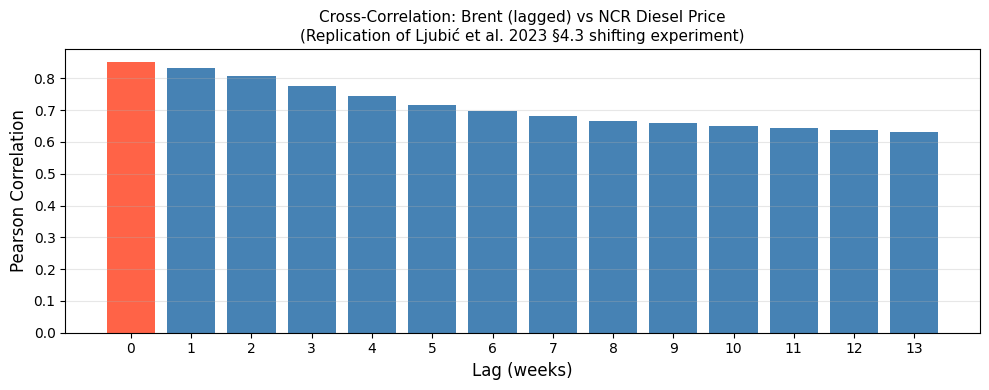

Peak correlation at lag: 0 week(s) | r = 0.8501
Note: lag 1 corresponds to the prior-week average used in the DOE pricing formula.
Bosnia (Ljubić et al.) found 32 days (≈4.5 weeks); PH has a more direct 1-week mechanism.


In [11]:
if 'brent_mean' in master.columns and 'diesel' in master.columns:
    brent  = master['brent_mean'].dropna()
    diesel = master['diesel'].dropna()
    idx    = brent.index.intersection(diesel.index)
    brent, diesel = brent[idx], diesel[idx]

    max_lag = 13  # weeks
    lags = range(0, max_lag + 1)
    correlations = [brent.shift(lag).corr(diesel) for lag in lags]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(lags, correlations, color=['tomato' if c == max(correlations) else 'steelblue' for c in correlations])
    ax.set_xlabel('Lag (weeks)', fontsize=12)
    ax.set_ylabel('Pearson Correlation', fontsize=12)
    ax.set_title('Cross-Correlation: Brent (lagged) vs NCR Diesel Price\n(Replication of Ljubić et al. 2023 §4.3 shifting experiment)', fontsize=11)
    ax.set_xticks(list(lags))
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('../outputs/02f_cross_correlation_brent_diesel.png', dpi=150, bbox_inches='tight')
    plt.show()

    best_lag = correlations.index(max(correlations))
    print(f'Peak correlation at lag: {best_lag} week(s) | r = {max(correlations):.4f}')
    print('Note: lag 1 corresponds to the prior-week average used in the DOE pricing formula.')
    print('Bosnia (Ljubić et al.) found 32 days (≈4.5 weeks); PH has a more direct 1-week mechanism.')

## 9. Price Change Direction Analysis

Per our methodology, the DOE enforces a minimum rollback on downward weeks (asymmetric by design). This section quantifies how often prices hike vs roll back vs hold — directly informing our classification task (Notebook 3B equivalent) and connecting to the Rockets-and-Feathers Hypothesis (Wen et al. 2025).

=== PRICE CHANGE DIRECTION ANALYSIS ===
DIESEL: Hikes=188 (51.1%) | Rollbacks=174 (47.3%) | No change=6 (1.6%)
RON91: Hikes=195 (52.4%) | Rollbacks=171 (46.0%) | No change=6 (1.6%)
RON95: Hikes=193 (51.9%) | Rollbacks=171 (46.0%) | No change=8 (2.2%)
RON97: Hikes=194 (52.2%) | Rollbacks=174 (46.8%) | No change=4 (1.1%)


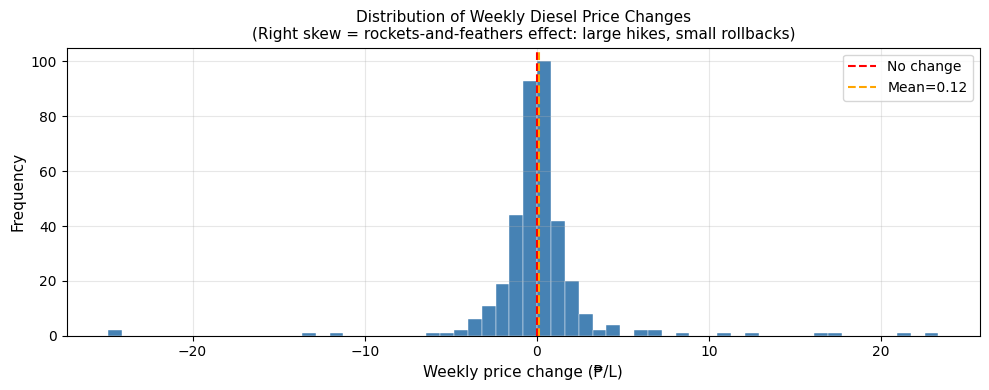

In [12]:
print('=== PRICE CHANGE DIRECTION ANALYSIS ===')
for product in available_products:
    changes = master[product].diff().dropna()
    hikes     = (changes > 0.01).sum()
    rollbacks = (changes < -0.01).sum()
    nochange  = ((changes >= -0.01) & (changes <= 0.01)).sum()
    total     = len(changes)
    print(f'{product.upper()}: Hikes={hikes} ({hikes/total*100:.1f}%) | Rollbacks={rollbacks} ({rollbacks/total*100:.1f}%) | No change={nochange} ({nochange/total*100:.1f}%)')

# Histogram of weekly price changes for diesel
if 'diesel' in master.columns:
    changes = master['diesel'].diff().dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(changes, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No change')
    ax.axvline(changes.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean={changes.mean():.2f}')
    ax.set_xlabel('Weekly price change (₱/L)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Distribution of Weekly Diesel Price Changes\n(Right skew = rockets-and-feathers effect: large hikes, small rollbacks)', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/02g_price_change_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10. Seasonality Decomposition (He 2023 §Seasonality Analysis)

He (2023) decomposed US gasoline prices into trend, seasonality, and residual components. We replicate this for diesel and RON 95. The seasonal component informs whether month dummies should be included in our linear models.

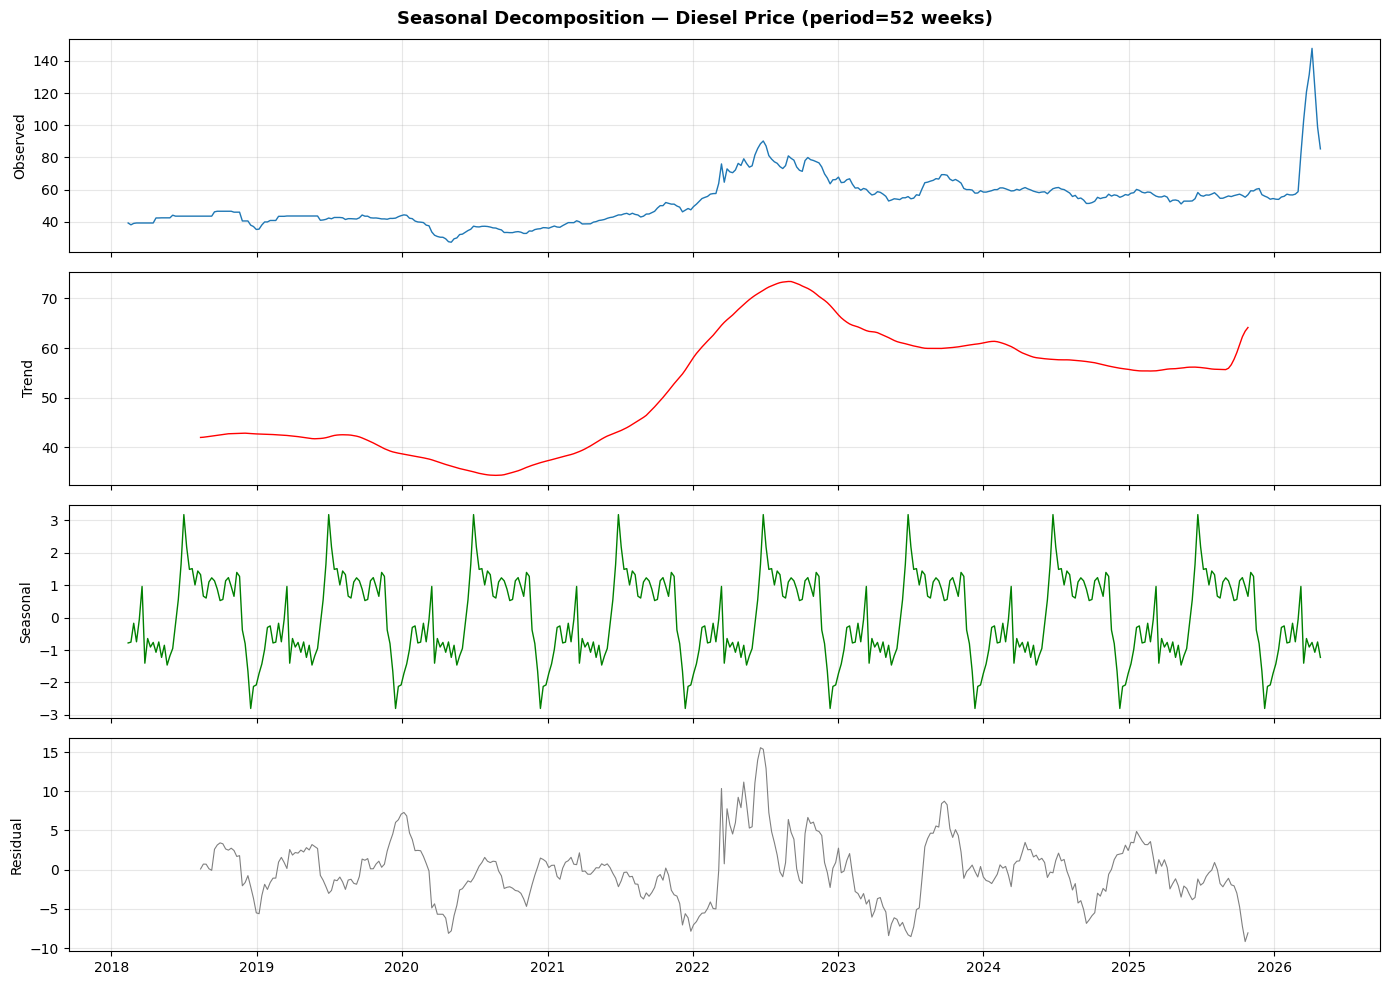

Monthly seasonal factors (avg by month):
  Month  1: -0.9523
  Month  2: -0.5702
  Month  3: -0.3492
  Month  4: -0.8881
  Month  5: -1.1460
  Month  6: +1.0002
  Month  7: +1.6050
  Month  8: +0.9814
  Month  9: +0.9364
  Month 10: +0.9434
  Month 11: +0.4696
  Month 12: -2.0624


In [13]:
if 'diesel' in master.columns:
    s = master['diesel'].dropna().asfreq('W-MON').ffill()
    if len(s) >= 104:
        decomp = seasonal_decompose(s, model='additive', period=52)
        fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
        axes[0].plot(decomp.observed,  linewidth=1.0); axes[0].set_ylabel('Observed')
        axes[1].plot(decomp.trend,     linewidth=1.0, color='red'); axes[1].set_ylabel('Trend')
        axes[2].plot(decomp.seasonal,  linewidth=1.0, color='green'); axes[2].set_ylabel('Seasonal')
        axes[3].plot(decomp.resid,     linewidth=0.8, color='gray'); axes[3].set_ylabel('Residual')
        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.suptitle('Seasonal Decomposition — Diesel Price (period=52 weeks)', fontsize=13, weight='bold')
        plt.tight_layout()
        plt.savefig('../outputs/02h_seasonality_decomposition.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Monthly seasonal factors (He 2023 Table 1)
        monthly_seasonal = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
        print('Monthly seasonal factors (avg by month):')
        for m, v in monthly_seasonal.items():
            print(f'  Month {m:2d}: {v:+.4f}')

## 11. Summary — EDA Conclusions for Feature Engineering

Summarize findings that directly drive decisions in the next notebook.

In [ ]:
print('=' * 70)
print('EDA CONCLUSIONS — DECISIONS FOR FEATURE ENGINEERING')
print('=' * 70)
print()
print('1. CRUDE OIL BENCHMARK')
print('   - Keep: Brent (primary) + Dubai (robustness feature)')
print('   - Drop: WTI (>0.95 correlation with Brent, US-centric)')
print()
print('2. STATIONARITY')
print('   - All price series in LEVELS are non-stationary (expected)')
print('   - First differences are stationary')
print('   - Implication: include both levels (for price prediction) and')
print('     returns (for asymmetry/RFH features) in feature engineering')
print()
print('3. LAG SELECTION')
print('   - Cross-correlation experiment confirms peak lag (see plot above)')
print('   - Our +3 day shift (W-FRI resample) encodes exactly lag-1 by construction')
print('   - Build lag 1–4 features for Brent, FX, MOPS in Feature Engineering notebook')
print()
print('4. SEASONALITY')
print('   - Seasonal component exists but is small relative to trend')
print('   - Include month dummies (He 2023 approach) as features')
print()
print('5. STRUCTURAL BREAKS')
print('   - TRAIN excise hikes (Jan 2018, 2019, 2020): encode as step dummies')
print('   - COVID lockdown (Mar 2020), Russia-Ukraine (Feb 2022): encode as event dummies')
print()
print('6. ROCKETS-AND-FEATHERS')
print('   - Price change distribution is right-skewed (hikes > rollbacks)')
print('   - Confirms Wen et al. (2025) asymmetry hypothesis applies to PH data')
print('   - Build r+ and r- asymmetric return features in Feature Engineering notebook')